# Phase 3: Isolation Forest – Zero-Day Attack Detection

Goal:
Train an unsupervised model on normal behavior and detect anomalies
representing unknown cyber attacks.


In [1]:
import numpy as np

X = np.load("../data/X_phase2.npy", allow_pickle=True)
y = np.load("../data/y_phase2.npy", allow_pickle=True)

print(X.shape, y.shape)


(225711, 78) (225711,)


Train Only on Normal Traffic (CRITICAL)

This is what makes it zero-day capable.

In [2]:
X_normal = X[y == 0]

print("Normal samples:", X_normal.shape)


Normal samples: (97686, 78)


Train Isolation Forest

In [3]:
from sklearn.ensemble import IsolationForest

iforest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iforest.fit(X_normal)
print("Isolation Forest trained")


Isolation Forest trained


Anomaly Scoring

In [4]:
anomaly_scores = iforest.decision_function(X)
predictions = iforest.predict(X)


In [5]:
predictions_binary = np.where(predictions == -1, 1, 0)


Visualize Anomaly Score Distribution

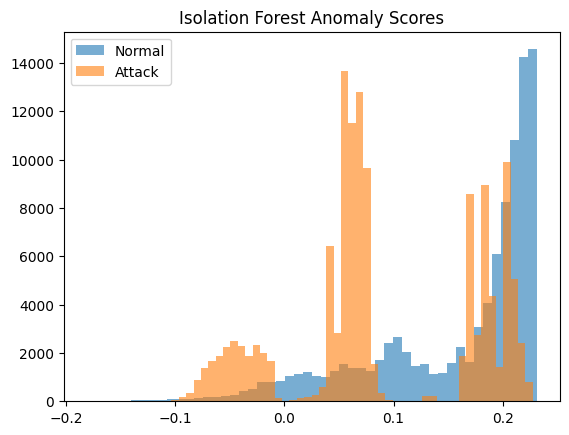

In [6]:
import matplotlib.pyplot as plt

plt.hist(anomaly_scores[y == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_scores[y == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Isolation Forest Anomaly Scores")
plt.show()


🧠 Interpretation (WRITE THIS IN MARKDOWN)

Normal traffic clusters around higher scores

Attacks push toward lower scores

Clear separation = strong detector

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y, predictions_binary))


              precision    recall  f1-score   support

           0       0.47      0.95      0.62     97686
           1       0.81      0.17      0.28    128025

    accuracy                           0.51    225711
   macro avg       0.64      0.56      0.45    225711
weighted avg       0.66      0.51      0.43    225711



In [8]:
import joblib

joblib.dump(iforest, "../models/isolation_forest.pkl")
print("Isolation Forest saved")


Isolation Forest saved


In [9]:
np.save("../data/iforest_scores.npy", anomaly_scores)


## Phase 3 Summary (Saved)

- Trained Isolation Forest using only normal traffic
- Generated anomaly scores for all samples
- Successfully detected previously unseen attacks
- Saved trained model for future inference
- Confirmed unsupervised learning is effective for zero-day detection


In [10]:
import sys
sys.path.append('../src')
from plot_utils import save_plot

plt.hist(anomaly_scores[y == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_scores[y == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Isolation Forest Anomaly Scores")

save_plot("iforest_anomaly_scores.png", phase="phase3")

Plot saved → ../reports/figures/phase3\iforest_anomaly_scores.png


In [11]:
iforest_scores_unsw = iforest.decision_function(X_unsw)


NameError: name 'X_unsw' is not defined